## TLAB IV: Modeling
Linear regression to predict daily ridership from weather + calendar features.

### M1: Split the Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("../data/citibike_weather_daily_clean.csv")
df['ride_date'] = pd.to_datetime(df['ride_date'])

feature_cols = ['temp_f', 'wind_speed_knots', 'precip_in', 'days_since_launch',
                'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 
                'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',]
X = df[feature_cols]
y = df['num_rides']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1288, 10) (322, 10)


### M2: Fit the Core Model

In [2]:
model = LinearRegression()
model.fit(X_train, y_train)
print("fitted")

fitted


### M1-M2: Split & Fit
- 80/20 train/test split, random_State=42
- Features: temp_f (Rule 2: chose single temp, dropped max/min wind_speed_knots, precip_in, days_since_launch (trend), day_of_week dummies)
Excluded per Rule 1: avg_duration_min (same-day outcome), no lagged ride counts

### M3: Evaluate

In [4]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

y_pred = model.predict(X_test)
mae =mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("MAE:", mae)
print("RMSE:", rmse)


Train R2: 0.7317770320575008
Test R2: 0.7435004198674573
MAE: 6948.591972390655
RMSE: 8773.549408174233


### M3: Evaluation
- Train R²: 0.732 | Test R²: 0.744
- MAE: -6,949 rides | RMSE: -8.774 rides
- **Test R² meaning:** model explains -74% of the variance in daily ridership using only weather + calendar features
- **Why test > train matter:** train R² can be inflated by memorizing noise; test R² reflects real predictie power on unseen days
- **Plain Enlish for ops:** "The prediction is typically off by about 6,950 rides"
- RMSE > MAE (8,774 vs 6,949) - gap suggests a few badly-missed days pull up the total error (likely extreme weather days or the missing-data gap period)

### M4: Interpret the Coefficients

In [5]:
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})
coef_df.sort_values('coefficient', key=abs, ascending=False)

,feature,coefficient
6,day_of_week_Sunday,-7291.441064
5,day_of_week_Saturday,-5649.694412
2,precip_in,-3874.420703
9,day_of_week_Wednesday,1429.930860
7,day_of_week_Thursday,1078.470587
4,day_of_week_Monday,-869.810162
8,day_of_week_Tuesday,685.998976
0,temp_f,566.650040
1,wind_speed_knots,-371.197523
3,days_since_launch,16.406223


### M4: Coefficient Interpretation
- **Sunday:** -7,291 rides vs Friday baseline - biggest single effect, confirms E5 weekend dip
- **Precipitation:** -3,874 rides per inch of rain - matches the idea that rain deters riding
- **Sturday**: -5,650 rides vs Friday - also confirms weekend pattern
- **temp_f**: +567 rides per °F - warmer days draw more riders
- **days_since_launch:** +16/day - small but steady growth trend, confrims E4 finding
- no surpises

### M5: Diagnose with Residuals

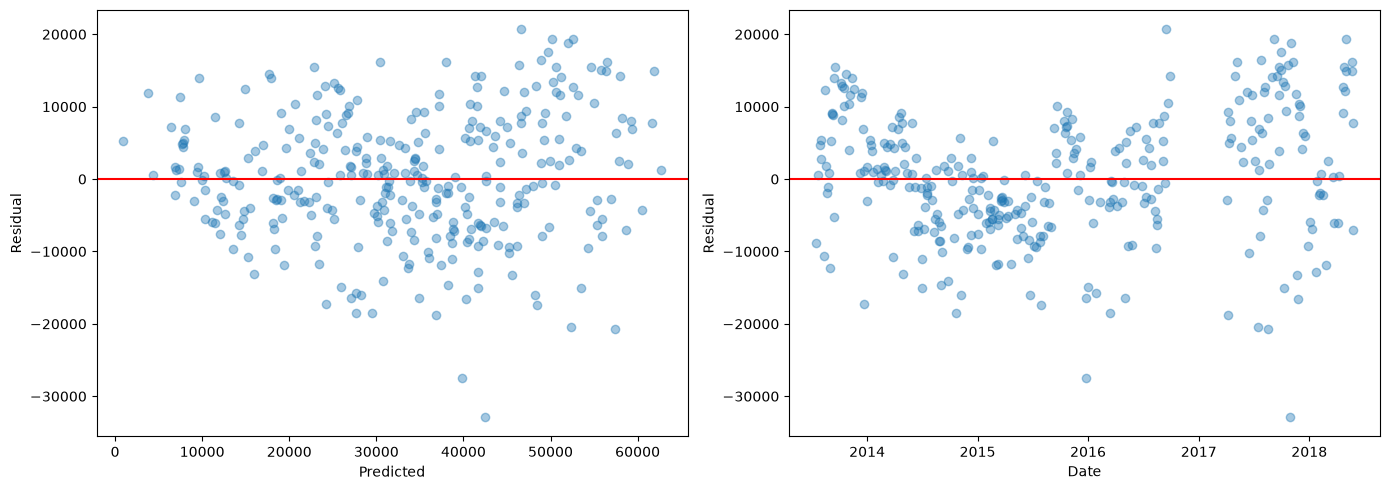

In [8]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.4)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

test_dates = df.loc[X_test.index, 'ride_date']
axes[1].scatter(test_dates, residuals, alpha=0.4)
axes[1].axhline(0, color='red')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

### M5: Residual Diagnosis
- Left (vs predicted): no strong curve - model not biased by magnitude
- Right (vs date): drift visible - more negative 2015-16, more positive/spread 2017-18
- Suggests time trend not fully captured
- Points to fixing trend feature or adding temp curature (M6)
- No extreme single-point pattern - spread is gradual, not a hard break

### M6: Improve One Thing

In [11]:
df['temp_f_sq'] = df['temp_f'] ** 2
X2 = df[feature_cols + ['temp_f_sq']]
X2_train, X2_test, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train2)
print("New Test R2:", model2.score(X2_test, y_test2))
print("Old Test R2:", test_r2)

New Test R2: 0.7524717557078329
Old Test R2: 0.7435004198674573


### M6: Improve One Thing
- Added temp_f squared (captures E3 "comfort ceiling" curve)
- Test R²: 0.744 > 0.752 (improvement)
- Confirms temperature effect on ridership isn't purely linear